# Heat Conduction in a Slab, a Cylinder and a Sphere

**Prepared by:** Prof. Alexander Dowling (2026)

This notebook is the PDE companion to Lecture 7. We take one transient conduction problem,
write it for three geometries at once, discretize space with the **method of lines**, and solve
the resulting differential-algebraic system with `Pyomo.dae`.

The physical problem and the idea of indexing the three geometries with a single shape parameter
are adapted from J. C. Kantor,
[*ND Pyomo Cookbook*](https://jckantor.github.io/ND-Pyomo-Cookbook/),
notebook 5.03 "Heat Conduction in Various Geometries". The derivation, the code and the numerical
experiments below are our own.

In [1]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
from pyomo.util.model_size import build_model_size_report
from scipy.special import j0, j1, jn_zeros

## Learning Objectives

* Nondimensionalize a transient conduction PDE and recognize the **Fourier number** as its only time scale
* Write **one** model that covers a slab, a cylinder and a sphere through a shape index $s$
* Apply the **method of lines**: discretize space first, then hand a DAE in time to `Pyomo.dae`
* Compare **finite difference**, **finite volume** and **finite element** spatial discretizations, and say where each belongs
* Handle the $r = 0$ **coordinate singularity** correctly
* Recognize a **dangling variable**: a derivative that appears in no discretization equation, which IPOPT
  will happily declare `optimal`

## The Physical Problem

A solid body, initially at uniform temperature $T_0$, is dropped at $t=0$ into a bath held at
$T_\infty$. The surface reaches the bath temperature immediately, and we want the temperature
everywhere inside as a function of time.

With constant thermal conductivity $k$, density $\rho$ and heat capacity $C_p$, and no source term,
the energy balance is

$$\rho C_p \frac{\partial T}{\partial t} = \nabla \cdot \left( k \nabla T \right) = k \nabla^2 T .$$

Divide by $\rho C_p$ and define the **thermal diffusivity** $\alpha = k / (\rho C_p)$, which has units
of length$^2$/time:

$$\frac{\partial T}{\partial t} = \alpha \nabla^2 T .$$

### One Equation, Three Geometries

The three classical bodies -- an infinite slab of half-thickness $R$, an infinite cylinder of
radius $R$, and a sphere of radius $R$ -- are all *one-dimensional*: temperature depends on a single
space coordinate $r$ measured from the center. In each case the Laplacian of a radially symmetric
field is

$$\nabla^2 T = \frac{1}{r^{s}} \frac{\partial}{\partial r}\left( r^{s} \frac{\partial T}{\partial r} \right)
            = \frac{\partial^2 T}{\partial r^2} + \frac{s}{r} \frac{\partial T}{\partial r},$$

where the **shape index** $s$ is

| Geometry | $s$ | $r$ measured from | Surface at |
| :-- | :-: | :-- | :-- |
| Slab (infinite plate, half-thickness $R$) | 0 | the midplane | $r = R$ |
| Cylinder (infinite, radius $R$) | 1 | the axis | $r = R$ |
| Sphere (radius $R$) | 2 | the center | $r = R$ |

For the slab, $s=0$ and the extra term vanishes -- Cartesian coordinates. For $s = 1$ and $s = 2$
the geometry contributes the $\tfrac{s}{r}\partial T/\partial r$ term, which is **singular at the
center**. That singularity is the interesting part of this notebook, so hold onto it.

### Nondimensionalization

Three scales are available: the temperature difference the body must cross, the body's own size, and
the time the heat needs to cross it. Define

$$T' = \frac{T - T_0}{T_\infty - T_0}, \qquad
  r' = \frac{r}{R}, \qquad
  t' = \frac{\alpha t}{R^2}.$$

Substituting, with $T = T_0 + (T_\infty - T_0) T'$, $r = R r'$ and $t = R^2 t' / \alpha$:

$$\frac{\partial T}{\partial t} = \frac{(T_\infty - T_0)\,\alpha}{R^2} \frac{\partial T'}{\partial t'},
\qquad
\frac{\partial^2 T}{\partial r^2} = \frac{T_\infty - T_0}{R^2} \frac{\partial^2 T'}{\partial r'^2},
\qquad
\frac{s}{r}\frac{\partial T}{\partial r} = \frac{T_\infty - T_0}{R^2}\, \frac{s}{r'}\frac{\partial T'}{\partial r'} .$$

Every term carries the same factor $\alpha (T_\infty - T_0)/R^2$, which therefore cancels:

$$\boxed{\;\frac{\partial T'}{\partial t'} = \frac{\partial^2 T'}{\partial r'^2}
   + \frac{s}{r'}\frac{\partial T'}{\partial r'}\;}$$

with

$$T'(0, r') = 0, \qquad T'(t', 1) = 1, \qquad \left.\frac{\partial T'}{\partial r'}\right|_{r'=0} = 0 .$$

Two things are worth noticing.

1. **No parameters survive.** The dimensionless problem depends only on $s$. Solve it once per
   geometry and you have solved it for every material, every size and every pair of temperatures.
2. **$t'$ is the Fourier number**, $\mathrm{Fo} = \alpha t / R^2$: the ratio of the time elapsed to the
   time heat needs to diffuse across the body. $\mathrm{Fo} \approx 1$ is "thoroughly heated."

The last condition is the **symmetry** (or **no-flux**) condition. It is not an extra physical
assumption -- it follows from the body being symmetric about $r'=0$, so no heat can cross the center.
It is, however, the boundary condition that will cause all the trouble.

From here on we drop the primes and write $T$, $r$, $t$ for the dimensionless quantities.

## The Method of Lines

We have one equation in **two** independent variables. `Pyomo.dae` is comfortable with either, but
the standard strategy for a parabolic PDE is to break the symmetry between them:

> **Method of lines.** Discretize the *spatial* derivatives on a fixed mesh
> $0 = r_0 < r_1 < \dots < r_N = 1$. What is left is a system of ODEs (here, a DAE, because the
> boundary rows are algebraic) in time alone, one equation per mesh point -- the "lines" of the name.

Writing $T_i(t) \approx T(t, r_i)$, the semi-discrete system is

$$\frac{dT_i}{dt} = \mathcal{L}_i\big(T_0, T_1, \dots, T_N\big), \qquad i = 1, \dots, N-1,$$

with $\mathcal{L}_i$ the discrete approximation to $\partial^2 T/\partial r^2 + (s/r)\,\partial T/\partial r$
at node $i$, plus algebraic rows at $i = 0$ (symmetry) and $i = N$ (the bath temperature).

Why this order?

* The **time** direction is an initial-value problem, and Lecture 7's machinery -- orthogonal
  collocation on finite elements -- is built exactly for that. We can hand the time direction to
  `dae.collocation` and get a high-order, stiffly stable integrator for free.
* The **space** direction is a boundary-value problem in disguise. All of its structure -- the
  boundary conditions, the coordinate singularity, the conservation properties -- is decided by how
  we build $\mathcal{L}_i$. Doing it deliberately, rather than letting a transformation do it for us,
  is the whole game.

In `Pyomo.dae` both directions are `ContinuousSet`s and both get a `TransformationFactory`, so the
method of lines is a way of *thinking* about the model rather than a different API. But it tells you
which transformation to worry about.

## Three Ways to Discretize Space

All three families replace $\mathcal{L}$ by a sparse linear operator on nodal values. They differ in
*what they ask the approximation to reproduce exactly*, and that choice is what makes one appropriate
and another awkward for a given problem.

### Finite difference (FD): match the Taylor series

Pick a stencil and choose coefficients so the truncation error is as high order as possible. On a
uniform mesh of spacing $h$,

$$\left.\frac{\partial^2 T}{\partial r^2}\right|_i \approx \frac{T_{i+1} - 2T_i + T_{i-1}}{h^2}
  + \mathcal{O}(h^2), \qquad
  \left.\frac{\partial T}{\partial r}\right|_i \approx \frac{T_{i+1} - T_{i-1}}{2h} + \mathcal{O}(h^2).$$

* **Cheap and transparent.** Every row is three numbers. This is what `dae.finite_difference` builds.
* **Appropriate when** the geometry is simple, the mesh is structured, and the coefficients ($k$, $\rho C_p$)
  are smooth.
* **Awkward when** you need a guarantee. FD approximates the *differential* equation pointwise; it makes
  no promise that the discrete system conserves energy, and it has nothing to say at a point where the
  differential equation itself is singular -- such as $r = 0$ here.

### Finite volume (FV): match the integral balance

Partition the domain into control volumes (here, shells) and integrate the conservation law over each
one. Using the self-adjoint form $\partial_t T = r^{-s}\,\partial_r ( r^{s} \partial_r T )$ and
integrating $r^{s}\,dr$ over the cell $[r_{i-1/2},\,r_{i+1/2}]$,

$$V_i \frac{dT_i}{dt} = \underbrace{r_{i+1/2}^{\,s}\left.\frac{\partial T}{\partial r}\right|_{i+1/2}}_{\text{heat in through the outer face}}
 - \underbrace{r_{i-1/2}^{\,s}\left.\frac{\partial T}{\partial r}\right|_{i-1/2}}_{\text{heat out through the inner face}},
\qquad V_i = \frac{r_{i+1/2}^{\,s+1} - r_{i-1/2}^{\,s+1}}{s+1}.$$

Approximating each face gradient by a two-point difference gives a scheme in which the flux leaving one
cell is *identically* the flux entering the next, so the sum over cells telescopes: the scheme conserves
energy to machine precision on any mesh, coarse or fine.

* **Appropriate when** conservation matters (reactors, flow, shocks), the mesh is unstructured, or the
  coefficients jump at an interface -- FV puts the interface on a face, where the flux is single valued.
* **Note what it does at $r = 0$:** the inner face of the first cell has area $r_{1/2}^{\,s} \to 0^{s} = 0$
  for $s > 0$. The symmetry condition is *structural*: no special case, no boundary condition to write.
  We will use this below.

### Finite element (FE): match a weighted residual

Expand $T(t,r) \approx \sum_j T_j(t)\,\phi_j(r)$ in basis functions and require the residual to be
orthogonal to a set of test functions. Galerkin FE integrates the weak form by parts, which lowers the
smoothness the solution must have and produces symmetric, provably stable operators; **orthogonal
collocation**, the variant used throughout Lecture 7, instead forces the residual to *vanish exactly*
at a set of collocation points inside each element.

* **Appropriate when** the geometry is complicated, the solution is smooth enough to reward high order,
  or you want error estimates and adaptivity on a rigorous footing.
* **In `Pyomo.dae`** this is `dae.collocation`. We use it in **time** below. It can also be applied in
  space -- and, as we will see, it inherits exactly the same $r=0$ trap as the finite difference scheme.

```{note}
FD, FV and FE coincide on the simplest problems: linear Galerkin FE with mass lumping on a uniform
1-D mesh gives the same three-point stencil as second-order central FD. They diverge as soon as the
mesh, the coefficients or the geometry stop being uniform -- which is the case that decides which one
you should have reached for.
```

## The Coordinate Singularity at $r = 0$

For $s > 0$ the term $\dfrac{s}{r}\dfrac{\partial T}{\partial r}$ is undefined at $r = 0$. The
*solution* is perfectly well behaved there -- by symmetry $\partial T/\partial r \to 0$ at least as fast
as $r$, so L'Hopital's rule gives $\lim_{r \to 0} \frac{s}{r}\frac{\partial T}{\partial r} = s\,\frac{\partial^2 T}{\partial r^2}$
-- but the *equation as written* cannot be evaluated at $r=0$. Two consequences for the discrete model:

1. **Never write the PDE row at $r = 0$.** In Pyomo, return `pyo.Constraint.Skip`. The row that takes
   its place is the symmetry condition $\partial T/\partial r|_{r=0} = 0$, which is what makes the
   center temperature well posed.
2. **Skip the corner $(t, r) = (0, 1)$.** The initial condition asks for $T = 0$ there and the boundary
   condition asks for $T = 1$. Both cannot hold. We keep the boundary condition (the bath is imposed
   from $t=0^+$ onward) and skip the initial condition at $r=1$. Physically this is the discontinuity
   that makes the surface flux infinite at $t = 0^+$; numerically it is simply one row we must not write
   twice.

The second point is routine bookkeeping. The first one hides a trap.

## A `Pyomo.dae` Model

Here is the model, written once for all three geometries. Read the three constraint rules first --
they are a direct transcription of the boxed PDE and its three side conditions.

In [2]:
def build_fd(s, nfe_r, center_bc, tf=0.5, nfe_t=30, ncp=3):
    """Transient conduction in a slab (s=0), cylinder (s=1) or sphere (s=2).

    Space: finite difference, CENTRAL, nfe_r elements on r in [0, 1].
    Time:  orthogonal collocation on finite elements (Radau), nfe_t elements, ncp points.

    Arguments:
        s: shape index. 0 = slab, 1 = cylinder, 2 = sphere.
        nfe_r: number of spatial finite elements.
        center_bc: how the symmetry condition at r=0 is imposed. One of
            "dangling"  -- dTdr[t, 0] == 0 and nothing else. LOOKS right, IS wrong.
            "forward"   -- supply the missing first-order defining equation for dTdr[t, 0].
            "forward2"  -- same, but a second-order three-point one-sided stencil.
        tf: final dimensionless time (Fourier number).
        nfe_t, ncp: time discretization.

    Returns:
        A ConcreteModel, already discretized, ready to solve.
    """
    m = pyo.ConcreteModel()

    # Two continuous sets: dimensionless time and dimensionless radius
    m.t = dae.ContinuousSet(bounds=(0, tf))
    m.r = dae.ContinuousSet(bounds=(0, 1))

    # Dimensionless temperature and its derivatives.
    # Everything here is dimensionless by construction, so there are no Pyomo
    # units to carry -- see [](./units_and_pyomo_dae.md) for the case where there are.
    m.T = pyo.Var(m.t, m.r, initialize=0.0)
    m.dTdt = dae.DerivativeVar(m.T, wrt=m.t)
    m.dTdr = dae.DerivativeVar(m.T, wrt=m.r)
    m.d2Tdr2 = dae.DerivativeVar(m.T, wrt=(m.r, m.r))

    @m.Constraint(m.t, m.r)
    def pde(m, t, r):
        # Skip t=0: the initial condition owns that row.
        # Skip r=0: the s/r term is singular there. The symmetry condition takes its place.
        # Skip r=1: the bath temperature owns that row.
        if t == 0 or r == 0 or r == 1:
            return pyo.Constraint.Skip
        return m.dTdt[t, r] == m.d2Tdr2[t, r] + (s / r) * m.dTdr[t, r]

    @m.Constraint(m.r)
    def ic(m, r):
        # Skip the corner (t, r) = (0, 1): the boundary condition wins there.
        if r == 1:
            return pyo.Constraint.Skip
        return m.T[0, r] == 0

    @m.Constraint(m.t)
    def bc_surface(m, t):
        return m.T[t, 1] == 1

    # --- discretize -------------------------------------------------------
    pyo.TransformationFactory("dae.finite_difference").apply_to(
        m, wrt=m.r, nfe=nfe_r, scheme="CENTRAL"
    )
    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.t, nfe=nfe_t, ncp=ncp, scheme="LAGRANGE-RADAU"
    )

    # --- symmetry at the center, AFTER discretization ---------------------
    # The mesh only exists once the transformation has run, and two of the three
    # options below need to name specific mesh points.
    rs = sorted(m.r)
    h = rs[1] - rs[0]

    if center_bc == "dangling":

        @m.Constraint(m.t)
        def bc_center(m, t):
            return m.dTdr[t, 0] == 0

    elif center_bc == "forward":
        for t in m.t:
            m.dTdr[t, 0].fix(0)  # symmetry

        @m.Constraint(m.t)
        def bc_center_def(m, t):
            if t == 0:
                return pyo.Constraint.Skip  # the initial condition already pins this row
            return m.dTdr[t, 0] * h == m.T[t, rs[1]] - m.T[t, rs[0]]

    elif center_bc == "forward2":
        for t in m.t:
            m.dTdr[t, 0].fix(0)  # symmetry

        @m.Constraint(m.t)
        def bc_center_def(m, t):
            if t == 0:
                return pyo.Constraint.Skip
            return m.dTdr[t, 0] * (2 * h) == (
                -3 * m.T[t, rs[0]] + 4 * m.T[t, rs[1]] - m.T[t, rs[2]]
            )

    else:
        raise ValueError(f"unknown center_bc: {center_bc}")

    # A simulation, not an optimization: a constant objective keeps IPOPT happy.
    m.obj = pyo.Objective(expr=0.0)
    return m


def solve_model(m, tee=False):
    """Solve with IPOPT and report the termination condition without asserting on it.

    We deliberately do NOT assert optimality here: half the point of this notebook is
    that `optimal` is not the same as `correct`.
    """
    results = pyo.SolverFactory("ipopt").solve(m, tee=tee)
    return results.solver.termination_condition

### The Reference Solution

Each of the three geometries has a classical separation-of-variables solution, so we can measure
error rather than eyeball it. For the dimensionless problem above:

$$\text{slab:}\quad T = 1 - \sum_{n=1}^{\infty} \frac{2(-1)^{n+1}}{\lambda_n}\cos(\lambda_n r)\,e^{-\lambda_n^2 t},
\qquad \lambda_n = \frac{(2n-1)\pi}{2}$$

$$\text{cylinder:}\quad T = 1 - \sum_{n=1}^{\infty} \frac{2}{\beta_n J_1(\beta_n)} J_0(\beta_n r)\,e^{-\beta_n^2 t},
\qquad J_0(\beta_n) = 0$$

$$\text{sphere:}\quad T = 1 + \frac{2}{\pi r}\sum_{n=1}^{\infty} \frac{(-1)^n}{n}\sin(n \pi r)\,e^{-n^2\pi^2 t}$$

In [3]:
def analytic(s, t, r, nterms=400):
    """Series solution of the dimensionless problem. Returns an array over r."""
    r = np.atleast_1d(np.asarray(r, dtype=float))
    out = np.zeros_like(r)
    if s == 0:
        n = np.arange(1, nterms)
        lam = (2 * n - 1) * np.pi / 2
        for k, rr in enumerate(r):
            out[k] = 1 - np.sum(2 * (-1) ** (n + 1) / lam * np.cos(lam * rr) * np.exp(-(lam**2) * t))
    elif s == 1:
        b = jn_zeros(0, nterms)
        for k, rr in enumerate(r):
            out[k] = 1 - np.sum(2 * j0(b * rr) * np.exp(-(b**2) * t) / (b * j1(b)))
    elif s == 2:
        n = np.arange(1, nterms)
        for k, rr in enumerate(r):
            if rr < 1e-12:  # the r -> 0 limit of sin(n pi r)/r
                out[k] = 1 + np.sum(2 * (-1) ** n * np.exp(-((n * np.pi) ** 2) * t))
            else:
                out[k] = 1 + (2 / (np.pi * rr)) * np.sum(
                    ((-1) ** n / n) * np.sin(n * np.pi * rr) * np.exp(-((n * np.pi) ** 2) * t)
                )
    else:
        raise ValueError("s must be 0, 1 or 2")
    return out


GEOMETRY = {0: "Slab", 1: "Cylinder", 2: "Sphere"}

## The Trap: A Derivative That Appears in No Equation

Here is the natural way to write the symmetry condition, and it is what `center_bc="dangling"` does:

```python
@m.Constraint(m.t)
def bc_center(m, t):
    return m.dTdr[t, 0] == 0
```

It reads exactly like the mathematics. It is also wrong, for a reason that has nothing to do with the
mathematics and everything to do with what `scheme="CENTRAL"` actually generates.

A central difference needs a neighbour on both sides. At an **interior** node it has one:

$$\texttt{dTdr}_i = \frac{T_{i+1} - T_{i-1}}{2h}, \qquad i = 1, \dots, N-1 .$$

At $i = 0$ there is no $T_{-1}$, so **`Pyomo.dae` writes no equation at all** for $\texttt{dTdr}[t, 0]$.
It is not set to a one-sided difference; it is not set to anything. It is a variable that appears in
no discretization equation -- a **dangling variable**. The constraint `bc_center` then does not impose
symmetry on the temperature field; it assigns a value to a number that touches nothing else in the model.

We can see this directly. `d1_disc_eq` is the component `Pyomo.dae` creates to define the first
derivative; ask it which mesh points it covers.

In [4]:
demo = build_fd(s=0, nfe_r=4, center_bc="dangling")

# The discretization equations are indexed by (t, r); collapse onto the r values.
r_with_d1 = sorted({r for (t, r) in demo.dTdr_disc_eq.keys()})
r_with_d2 = sorted({r for (t, r) in demo.d2Tdr2_disc_eq.keys()})

print("mesh points in r                    :", sorted(demo.r))
print("r values where dTdr is DEFINED      :", r_with_d1)
print("r values where d2Tdr2 is DEFINED    :", r_with_d2)
print("r values with NO dTdr equation      :", sorted(set(demo.r) - set(r_with_d1)))

mesh points in r                    : [0, 0.25, 0.5, 0.75, 1]
r values where dTdr is DEFINED      : [0.25, 0.5, 0.75]
r values where d2Tdr2 is DEFINED    : [0.25, 0.5, 0.75]
r values with NO dTdr equation      : [0, 1]


Neither endpoint gets a defining equation for the first derivative, and neither gets one for the second.
At $r=1$ that is harmless: the PDE row is skipped there and the bath temperature is imposed directly.
At $r=0$ it is fatal, because the PDE row is skipped there *too*, and the only thing we wrote in its
place was a constraint on a variable that leads nowhere.

```{warning}
This is **not** a quirk of `scheme="CENTRAL"` in `dae.finite_difference`. `dae.collocation` behaves the
same way: with `LAGRANGE-RADAU` the collocation points of each element exclude its left endpoint, so
the derivative at $r = 0$ has no defining equation either. Any scheme whose stencil omits the left end
of the domain leaves a Neumann boundary condition there attached to nothing.
```

### Counting Degrees of Freedom

The symptom is visible before you ever call the solver. This is a **simulation**: the temperature field
is completely determined by the data, so a correctly posed model must have **zero** degrees of freedom.

In [5]:
for bc in ["dangling", "forward", "forward2"]:
    report = build_model_size_report(build_fd(s=0, nfe_r=40, center_bc=bc)).activated
    dof = report["variables"] - report["constraints"]
    print(f"center_bc = {bc:9s}   variables = {report['variables']:5d}   "
          f"constraints = {report['constraints']:5d}   DOF = {dof:4d}")

center_bc = dangling    variables = 14610   constraints = 14520   DOF =   90


center_bc = forward     variables = 14519   constraints = 14519   DOF =    0


center_bc = forward2    variables = 14519   constraints = 14519   DOF =    0


The dangling model has one spare degree of freedom for every time point at which the PDE is enforced.
Each of them is a center temperature nobody constrained. IPOPT is being asked to *optimize* a constant
objective over a 90-dimensional manifold of solutions -- and it will pick one, report `optimal`, and
say nothing.

```{note}
This is precisely the class of structural defect the
[IDAES Diagnostics Toolbox](https://idaes-pse.readthedocs.io/en/stable/explanations/model_diagnostics/index.html)
is built to surface: `DiagnosticsToolbox.report_structural_issues()` reports the degree-of-freedom count
and, more usefully, lists variables that appear in no constraint. On a model with hundreds of thousands
of rows you will not spot a dangling derivative by reading the code. We are not going to turn this
notebook into a diagnostics tutorial -- but run the toolbox on every `Pyomo.dae` model you build.
```

### The Answer Depends on the Initial Guess

A model with 90 unconstrained degrees of freedom and no objective has no unique answer. The quickest
way to prove that to yourself is to change the initial guess and re-solve.

In [6]:
print(f"{'geometry':10s} {'guess':>7s} {'T(t_f, 0)':>12s} {'exact':>12s} {'|error|':>10s}   status")
for s in [0, 1, 2]:
    exact = analytic(s, 0.5, 0.0)[0]
    for guess in [0.0, 0.5, 1.0, -2.0]:
        m = build_fd(s=s, nfe_r=40, center_bc="dangling")
        for v in m.T.values():
            v.set_value(guess)
        status = solve_model(m)
        Tc = pyo.value(m.T[0.5, 0])
        print(f"{GEOMETRY[s]:10s} {guess:7.1f} {Tc:12.6f} {exact:12.6f} "
              f"{abs(Tc - exact):10.2e}   {status}")

geometry     guess    T(t_f, 0)        exact    |error|   status


Slab           0.0    -0.097189     0.629223   7.26e-01   optimal


Slab           0.5    -0.061740     0.629223   6.91e-01   optimal


Slab           1.0    -0.026291     0.629223   6.56e-01   optimal


Slab          -2.0    -0.238984     0.629223   8.68e-01   optimal


...

Cylinder      -2.0     0.909403     0.911110   1.71e-03   optimal


Sphere         0.0     0.985540     0.985616   7.66e-05   optimal


Sphere         0.5     0.985540     0.985616   7.64e-05   optimal


Sphere         1.0     0.985540     0.985616   7.62e-05   optimal


Sphere        -2.0     0.985539     0.985616   7.74e-05   optimal


Every one of those solves reported `optimal`.

For the **slab** the answer moves with the initial guess and is not merely inaccurate but *unphysical*:
a center temperature below zero, in a body that started at zero and is being heated from all sides. For
the **cylinder** and the **sphere** the answer barely moves and is nearly right -- which is worse, not
better. The $s/r$ term at the first interior node carries a coefficient that grows like $1/h$, and it
accidentally pins the center temperature well enough to hide the missing equation. **The defect is
silent in two of the three geometries.** If you had only ever run the sphere, you would have shipped
this model.

## The Fix: Supply the Equation the Scheme Did Not Write

The symmetry condition is two statements, and `CENTRAL` gives us neither:

1. a **defining equation** that ties $\texttt{dTdr}[t,0]$ to the temperature field, and
2. the **physical condition** that its value is zero.

So write both. Fix the derivative variable at zero (statement 2 -- fixing removes the variable rather
than adding a row, which keeps the model square), and add a one-sided difference for statement 1:

```python
for t in m.t:
    m.dTdr[t, 0].fix(0)                       # symmetry

@m.Constraint(m.t)
def bc_center_def(m, t):                      # the equation CENTRAL never wrote
    if t == 0:
        return pyo.Constraint.Skip            # the initial condition already pins this row
    return m.dTdr[t, 0] * h == m.T[t, rs[1]] - m.T[t, rs[0]]
```

Together these collapse to $T_1 = T_0$: the first-order statement that the profile is flat at the
center. That is `center_bc="forward"`. The three-point version,

$$\left.\frac{\partial T}{\partial r}\right|_0 \approx \frac{-3T_0 + 4T_1 - T_2}{2h} + \mathcal{O}(h^2),$$

is `center_bc="forward2"` and restores second-order accuracy at the boundary to match the interior.

```{warning}
Skipping `bc_center_def` at $t = 0$ is not cosmetic. The initial condition already sets
$T_0 = T_1 = 0$ there, so writing the row at $t=0$ makes the system square but **rank deficient**, and
IPOPT stops with *"Too few degrees of freedom"*. Row counting is necessary but not sufficient -- you
have to know which rows are independent.
```

### Mesh Refinement Tells the Truth

A dangling variable does not announce itself in a single solve. It announces itself under refinement:
a consistent scheme's error must go to zero with $h$, and an underdetermined one's does not have to.

In [7]:
NFE_LIST = [10, 20, 40, 80, 160]
TF = 0.5

conv = {}
for s in [0, 1, 2]:
    exact = analytic(s, TF, 0.0)[0]
    for bc in ["dangling", "forward", "forward2"]:
        errs = []
        for n in NFE_LIST:
            m = build_fd(s=s, nfe_r=n, center_bc=bc)
            solve_model(m)
            errs.append(abs(pyo.value(m.T[TF, 0]) - exact))
        conv[(s, bc)] = np.array(errs)

for s in [0, 1, 2]:
    print(f"\n{GEOMETRY[s]}  (s = {s}):  |T(t_f, 0) - exact|   at   t_f = {TF}")
    print("  " + "".join(f"{'h=1/'+str(n):>12s}" for n in NFE_LIST) + f"{'order':>9s}")
    for bc in ["dangling", "forward", "forward2"]:
        e = conv[(s, bc)]
        order = np.log2(e[-2] / e[-1])
        print(f"  {bc:9s}" + "".join(f"{v:12.3e}" for v in e) + f"{order:9.2f}")


Slab  (s = 0):  |T(t_f, 0) - exact|   at   t_f = 0.5
        h=1/10      h=1/20      h=1/40      h=1/80     h=1/160    order
  dangling    7.388e-01   7.311e-01   7.264e-01   7.238e-01   7.224e-01     0.00
  forward     4.710e-02   2.324e-02   1.153e-02   5.741e-03   2.865e-03     1.00
  forward2    6.573e-05   3.075e-05   9.391e-06   2.557e-06   6.653e-07     1.94

Cylinder  (s = 1):  |T(t_f, 0) - exact|   at   t_f = 0.5
        h=1/10      h=1/20      h=1/40      h=1/80     h=1/160    order
  dangling    3.195e-02   7.151e-03   1.678e-03   4.205e-04   1.079e-04     1.96
  forward     3.026e-03   8.788e-04   2.485e-04   6.918e-05   1.904e-05     1.86
  forward2    8.651e-04   2.256e-04   5.707e-05   1.432e-05   3.582e-06     2.00

Sphere  (s = 2):  |T(t_f, 0) - exact|   at   t_f = 0.5
        h=1/10      h=1/20      h=1/40      h=1/80     h=1/160    order
  dangling    2.157e-03   3.927e-04   7.662e-05   1.590e-05   3.745e-06     2.09
  forward     2.273e-04   5.712e-05   1.430e-05  

Read the `order` column: it is $\log_2$ of the ratio of the last two errors, so 1.0 means first order
in $h$, 2.0 means second order, and $\approx 0$ means the error is not going anywhere.

Now plot it. The slab is the clean case, because there is no $s/r$ term to accidentally rescue the
dangling model.

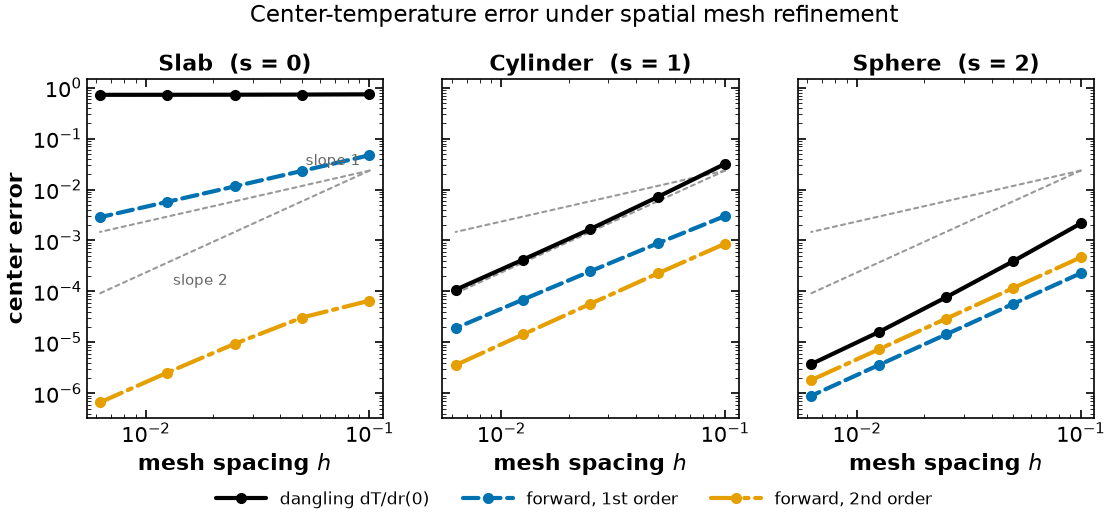

In [8]:
h = 1.0 / np.array(NFE_LIST, dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)

LABELS = {
    "dangling": "dangling dT/dr(0)",
    "forward": "forward, 1st order",
    "forward2": "forward, 2nd order",
}

for ax, s in zip(axes, [0, 1, 2]):
    for bc in ["dangling", "forward", "forward2"]:
        ax.loglog(h, conv[(s, bc)], marker="o", markersize=7, label=LABELS[bc])
    # reference slopes, drawn in grey so they never compete with the data
    ax.loglog(h, 0.5 * conv[(0, "forward")][0] * (h / h[0]), color="0.6", lw=1.5,
              ls=(0, (2, 2)), zorder=0)
    ax.loglog(h, 0.5 * conv[(0, "forward")][0] * (h / h[0]) ** 2, color="0.6", lw=1.5,
              ls=(0, (2, 2)), zorder=0)
    ax.set_title(f"{GEOMETRY[s]}  (s = {s})")
    ax.set_xlabel("mesh spacing $h$")

axes[0].set_ylabel("center error")
axes[0].annotate("slope 1", xy=(h[0], 0.5 * conv[(0, "forward")][0]),
                 xytext=(-46, 4), textcoords="offset points", fontsize=11, color="0.4")
axes[0].annotate("slope 2", xy=(h[3], 0.5 * conv[(0, "forward")][0] * (h[3] / h[0]) ** 2),
                 xytext=(4, -16), textcoords="offset points", fontsize=11, color="0.4")
fig.suptitle("Center-temperature error under spatial mesh refinement", y=1.05)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, -0.13))
plt.show()

The slab panel is the one to remember: the dangling model's error flattens out and stays there. Refining
the mesh -- the one move that fixes almost every other discretization problem -- does nothing at all,
because the error is not a truncation error. There is no equation to converge.

In the cylinder and sphere panels the dangling curve *does* fall, which is exactly why this defect
survives code review. It is producing plausible numbers for the wrong reason.

## The Correct Model, Geometry by Geometry

The builder is the same in all three cases. What changes is *why* each piece is correct.

### Slab, $s = 0$

The PDE is $\partial_t T = \partial_r^2 T$ -- no singular term at all. We could legitimately write the
PDE row at $r=0$ and drop the symmetry condition; the slab is only "half" of a symmetric plate of
thickness $2R$, and $r=0$ is its midplane. We do **not**, for two reasons. `scheme="CENTRAL"` supplies
no second-derivative equation at $r=0$ either, so that row would need a one-sided stencil of its own;
and keeping the same skip-plus-symmetry structure for all three geometries means one code path, tested
three ways. So: skip the PDE at $r=0$, impose $\partial_r T|_0 = 0$ **with its defining equation**.

### Cylinder, $s = 1$

Now the skip at $r = 0$ is mandatory: $\frac{1}{r}\partial_r T$ cannot be evaluated there. The symmetry
condition is doing real work -- it is the *only* equation that determines the axis temperature, and
without a defining equation for $\texttt{dTdr}[t,0]$ the axis is unconstrained. Every interior row
$i = 1, \dots, N-1$ has $r_i = i h > 0$, so the $1/r$ coefficient is finite everywhere it is used; it is
large ($1/h$) at the first interior node, which is why the discrete operator is stiff near the axis and
why an $\mathcal{O}(h^2)$ symmetry stencil is worth having.

### Sphere, $s = 2$

Identical structure, with $2/r$. The $1/r$ weighting is stronger, so the near-center rows dominate the
Jacobian even more, and the "accidentally almost right" behaviour of the dangling model above is
strongest here. Nothing about the fix changes.

In all three cases the count works out the same way, per time point: $N$ unknowns
$T_0, \dots, T_{N-1}$ (the surface value $T_N$ is imposed), $N-1$ PDE rows at the interior nodes, and
one symmetry row at the center. $N$ equations, $N$ unknowns, zero degrees of freedom -- which is what
the table above confirms.

In [9]:
# Production models: second-order symmetry stencil, fine mesh.
TIMES = [0.01, 0.05, 0.15, 0.5]

solutions = {}
for s in [0, 1, 2]:
    m = build_fd(s=s, nfe_r=80, center_bc="forward2", tf=max(TIMES), nfe_t=50, ncp=3)
    status = solve_model(m)
    rgrid = np.array(sorted(m.r))
    profiles = {}
    for tt in TIMES:
        # the collocation mesh contains every element boundary, and TIMES were
        # chosen to land on one; assert rather than silently interpolate
        assert tt in m.t, f"t = {tt} is not a mesh point"
        profiles[tt] = np.array([pyo.value(m.T[tt, r]) for r in rgrid])
    solutions[s] = (rgrid, profiles)
    err = max(
        np.max(np.abs(profiles[tt] - analytic(s, tt, rgrid))) for tt in TIMES if tt >= 0.05
    )
    print(f"{GEOMETRY[s]:9s} status = {status},  max |numeric - series| over r for Fo >= 0.05: {err:.2e}")

Slab      status = optimal,  max |numeric - series| over r for Fo >= 0.05: 4.26e-05


Cylinder  status = optimal,  max |numeric - series| over r for Fo >= 0.05: 8.26e-05


Sphere    status = optimal,  max |numeric - series| over r for Fo >= 0.05: 1.34e-04


```{note}
The comparison above excludes $\mathrm{Fo} = 0.01$. At very short times the profile is a thin boundary
layer near the surface, and both sides of the comparison struggle: the truncated series converges
slowly, and an 80-element uniform mesh under-resolves the layer. That is a genuine limitation of a
uniform mesh, not a bug -- and a good argument for the graded meshes that finite element and finite
volume codes make easy.
```

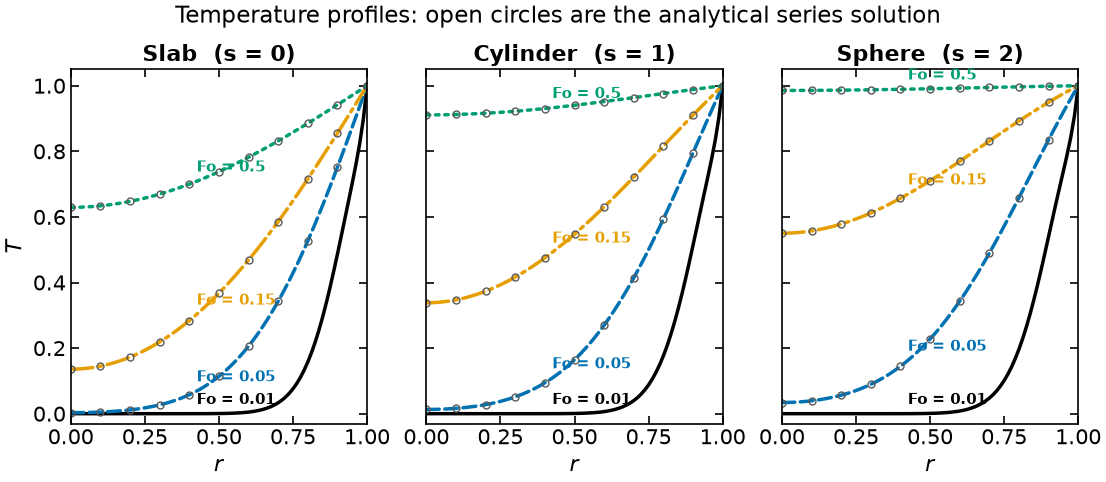

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=True)

for ax, s in zip(axes, [0, 1, 2]):
    rgrid, profiles = solutions[s]
    for tt in TIMES:
        (line,) = ax.plot(rgrid, profiles[tt], lw=2.5)
        # direct labelling: a legend keyed only by colour dies in black and white
        j = int(0.42 * len(rgrid))
        ax.annotate(f"Fo = {tt:g}", xy=(rgrid[j], profiles[tt][j]),
                    xytext=(0, 7), textcoords="offset points",
                    fontsize=11, color=line.get_color(), fontweight="bold")
    # series solution, as sparse open markers, for the two well-resolved times
    for tt in TIMES[1:]:
        ax.plot(rgrid[::8], analytic(s, tt, rgrid[::8]), ls="none", marker="o",
                mfc="none", mec="0.35", ms=5, mew=1.0)
    ax.set_xlabel("$r$")
    ax.set_title(f"{GEOMETRY[s]}  (s = {s})")
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.03, 1.05)

axes[0].set_ylabel("$T$")
fig.suptitle("Temperature profiles: open circles are the analytical series solution", y=1.02)
plt.show()

At a fixed Fourier number the sphere is furthest along and the slab is furthest behind. That is the
surface-to-volume ratio: per unit volume, a sphere presents $3/R$ of surface, a cylinder $2/R$, a slab
$1/R$. The shape index $s$ is doing exactly that bookkeeping, and it is the reason $\mathrm{Fo}$ alone
is not enough to say "how hot is it inside" without also saying which shape you meant.

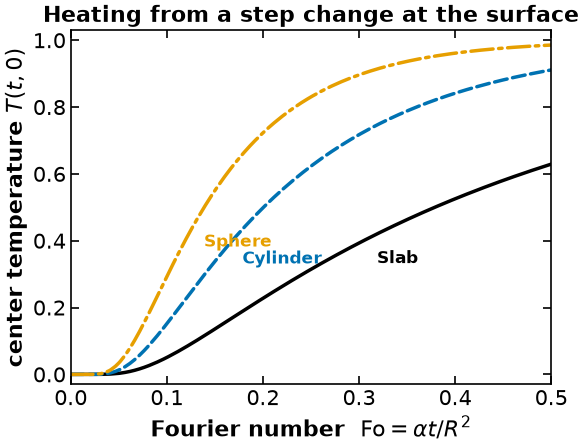

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 4.6))

for s in [0, 1, 2]:
    m = build_fd(s=s, nfe_r=80, center_bc="forward2", tf=0.5, nfe_t=50, ncp=3)
    solve_model(m)
    tgrid = np.array(sorted(m.t))
    Tc = np.array([pyo.value(m.T[t, 0]) for t in tgrid])
    (line,) = ax.plot(tgrid, Tc, lw=2.5)
    frac = {0: 0.62, 1: 0.34, 2: 0.26}[s]  # keep the three labels off each other
    k = int(frac * len(tgrid))
    ax.annotate(GEOMETRY[s], xy=(tgrid[k], Tc[k]), xytext=(6, -18),
                textcoords="offset points", fontsize=12,
                color=line.get_color(), fontweight="bold")

ax.set_xlabel("Fourier number  $\\mathrm{Fo} = \\alpha t / R^2$")
ax.set_ylabel("center temperature $T(t, 0)$")
ax.set_xlim(0, 0.5)
ax.set_ylim(-0.03, 1.03)
ax.set_title("Heating from a step change at the surface")
plt.show()

## The Finite Volume Alternative

Everything above was finite difference. It is worth building the finite volume version of the same
problem, because it makes a structural point that no amount of care with stencils can:

> In the finite volume formulation the symmetry condition at $r = 0$ **is not a boundary condition at
> all.** It is a consequence of the geometry, and there is nothing to forget.

Place $N$ shells with faces at $r_{i+1/2} = (i+1)h$, $h = 1/N$, and unknowns at the cell centers. The
balance on shell $i$ is the discrete form of the integral law from earlier,

$$V_i \frac{dT_i}{dt} = A_{i+1/2}\frac{T_{i+1} - T_i}{h} - A_{i-1/2}\frac{T_i - T_{i-1}}{h},
\qquad A_{i+1/2} = r_{i+1/2}^{\,s}, \quad V_i = \frac{r_{i+1/2}^{\,s+1} - r_{i-1/2}^{\,s+1}}{s+1}.$$

For the innermost shell, $r_{-1/2} = 0$ and therefore $A_{-1/2} = 0^{s} = 0$ for $s > 0$: **the inner
face has no area, so no heat can cross it.** For the slab, $s = 0$ makes $A_{-1/2} = 1$, and we set the
inner flux to zero by symmetry -- one line, and the only geometry-specific line in the model.

At the outer face of the last shell the temperature is known, and the half-cell distance from the
center of that shell to the surface is $h/2$, so the flux is $A_{N-1/2}\,(1 - T_{N-1}) / (h/2)$.

Note also that there is no `DerivativeVar` in space at all. The method of lines is explicit here: the
only `ContinuousSet` is time.

In [12]:
def build_fv(s, ncells, tf=0.5, nfe_t=30, ncp=3):
    """Finite volume discretization of the same problem.

    Shells of equal thickness h = 1/ncells, unknowns at cell centers, fluxes at faces.
    Conservative by construction, and the symmetry condition at r = 0 is structural.
    """
    h = 1.0 / ncells
    faces = np.linspace(0.0, 1.0, ncells + 1)
    centers = 0.5 * (faces[:-1] + faces[1:])
    area = faces**s                                     # A = r^s at each face
    vol = (faces[1:] ** (s + 1) - faces[:-1] ** (s + 1)) / (s + 1)

    m = pyo.ConcreteModel()
    m.t = dae.ContinuousSet(bounds=(0, tf))
    m.c = pyo.RangeSet(0, ncells - 1)                   # cell index; NOT a ContinuousSet
    m.T = pyo.Var(m.t, m.c, initialize=0.0)
    m.dTdt = dae.DerivativeVar(m.T, wrt=m.t)

    @m.Constraint(m.t, m.c)
    def shell(m, t, i):
        if t == 0:
            return pyo.Constraint.Skip
        if i == 0:
            flux_in = 0.0                               # zero face area (s>0) or symmetry (s=0)
        else:
            flux_in = area[i] * (m.T[t, i] - m.T[t, i - 1]) / h
        if i == ncells - 1:
            flux_out = area[i + 1] * (1.0 - m.T[t, i]) / (h / 2)   # bath at r = 1
        else:
            flux_out = area[i + 1] * (m.T[t, i + 1] - m.T[t, i]) / h
        return vol[i] * m.dTdt[t, i] == flux_out - flux_in

    @m.Constraint(m.c)
    def ic(m, i):
        return m.T[0, i] == 0

    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.t, nfe=nfe_t, ncp=ncp, scheme="LAGRANGE-RADAU"
    )
    m.obj = pyo.Objective(expr=0.0)
    m.centers = centers
    return m

In [13]:
NC_LIST = [10, 20, 40, 80]
print(f"{'geometry':10s} {'DOF':>5s}   " + "".join(f"{'N='+str(n):>12s}" for n in NC_LIST) + f"{'order':>9s}")
fv_conv = {}
for s in [0, 1, 2]:
    errs = []
    for n in NC_LIST:
        m = build_fv(s=s, ncells=n)
        solve_model(m)
        # compare at the first cell center, r = h/2
        errs.append(abs(pyo.value(m.T[0.5, 0]) - analytic(s, 0.5, m.centers[0])[0]))
    fv_conv[s] = np.array(errs)
    rep = build_model_size_report(build_fv(s=s, ncells=40)).activated
    order = np.log2(errs[-2] / errs[-1])
    print(f"{GEOMETRY[s]:10s} {rep['variables'] - rep['constraints']:5d}   "
          + "".join(f"{v:12.3e}" for v in errs) + f"{order:9.2f}")

geometry     DOF           N=10        N=20        N=40        N=80    order


Slab           0      1.318e-03   3.299e-04   8.251e-05   2.063e-05     2.00


Cylinder       0      9.179e-04   2.294e-04   5.734e-05   1.433e-05     2.00


Sphere         0      3.672e-04   9.172e-05   2.293e-05   5.734e-06     2.00


Zero degrees of freedom in every geometry, second-order convergence, and no symmetry constraint anywhere
in the model. That is the argument for finite volume in one table: not that it is more accurate -- on
this uniform mesh it is not dramatically so -- but that the condition we spent this whole notebook
getting wrong cannot be gotten wrong.

The price is that a finite volume model is *yours to write*. `Pyomo.dae` will not build it for you,
you do not get a `DerivativeVar` to inspect, and the cell-center unknowns do not sit on the boundary,
so reporting a surface value takes an extra half-cell extrapolation. Which is the right trade depends
on the problem, and that is the point of knowing all three families.

## Take-Home Messages

1. **Nondimensionalize first.** Three geometries, any material, any size and any temperature pair reduce
   to one equation in one parameter $s$, with the Fourier number as the clock.
2. **The method of lines is a decision, not a syntax.** Discretizing space first is what lets you hand
   the time direction to Lecture 7's collocation machinery and concentrate on the spatial operator,
   where the physics lives.
3. **Finite difference, finite volume and finite element differ in what they reproduce exactly** --
   the Taylor series, the integral balance, or a weighted residual. Reach for FV when conservation or
   an interface matters, FE when the geometry or the accuracy demands it, FD when neither does.
4. 🔴 **A Neumann boundary condition written on a `DerivativeVar` may constrain nothing.** `CENTRAL`
   finite differences and Radau collocation both leave the derivative at the left endpoint of the domain
   with **no defining equation**. Writing `m.dTdr[t, 0] == 0` then assigns a value to a dangling
   variable, and the center temperature is unconstrained.
5. **`optimal` is not `correct`.** Every wrong solve in this notebook terminated cleanly. The two things
   that caught it were a **degree-of-freedom count** -- a simulation must have zero -- and **mesh
   refinement**, which turns a structural defect into a visible plateau. Do both, and run the IDAES
   Diagnostics Toolbox on anything larger than this.
6. **Test on the geometry where the bug is loud.** The defect was obvious in the slab and nearly
   invisible in the sphere. A model verified only on the forgiving case is not verified.

## Try It Yourself

1. Change `scheme="CENTRAL"` to `scheme="BACKWARD"` in `build_fd` and predict, before running it, which
   endpoint now loses its defining equation and what breaks. (Check with `demo.dTdr_disc_eq.keys()`.)
2. Replace `dae.finite_difference` in space with `dae.collocation` and confirm that the dangling
   derivative at $r=0$ is still there.
3. Add a Robin (convective) boundary condition at the surface, $-\partial_r T|_{r=1} = \mathrm{Bi}\,(T(t,1) - 1)$,
   where $\mathrm{Bi} = hR/k$ is the Biot number. Which endpoint does `CENTRAL` leave undefined now, and
   what does that imply about which one-sided stencil you owe the model? Recover the results above as
   $\mathrm{Bi} \to \infty$.
4. Grade the mesh toward $r=1$ so the short-time boundary layer is resolved, and redo the
   $\mathrm{Fo}=0.01$ comparison. `ContinuousSet(initialize=[...])` accepts an explicit list of points.